In [22]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.cluster import OPTICS, cluster_optics_dbscan, HDBSCAN, DBSCAN

In [24]:
day24 = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/whole_slide/o8p_day24_s12.csv").drop(columns=["label",'nuclei_bounds']).rename(columns={"nuclei_i":"i", "nuclei_j":"j"})
coords = day24[["i","j"]]
X = coords.values

In [7]:
distances = pairwise_distances(coords, metric="euclidean")

In [11]:
clust = OPTICS(metric="euclidean")
clust.fit(coords)

,"min_samples min_samples: int > 1 or float between 0 and 1, default=5The number of samples in a neighborhood for a point to be considered asa core point. Also, up and down steep regions can't have more than``min_samples`` consecutive non-steep points. Expressed as an absolutenumber or a fraction of the number of samples (rounded to be at least2).",5
,"max_eps max_eps: float, default=np.infThe maximum distance between two samples for one to be considered asin the neighborhood of the other. Default value of ``np.inf`` willidentify clusters across all scales; reducing ``max_eps`` will resultin shorter run times.",inf
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Any metric from scikit-learnor :mod:`scipy.spatial.distance` can be used.If `metric` is a callable function, it is called on eachpair of instances (rows) and the resulting value recorded. The callableshould take two arrays as input and return one value indicating thedistance between them. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string. If metric is""precomputed"", `X` is assumed to be a distance matrix and must besquare.Valid values for metric are:- from scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan']- from scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']Sparse matrices are only supported by scikit-learn metrics.See :mod:`scipy.spatial.distance` for details on these metrics... note:: `'kulsinski'` is deprecated from SciPy 1.9 and will be removed in SciPy 1.11.",'euclidean'
,"p p: float, default=2Parameter for the Minkowski metric from:class:`~sklearn.metrics.pairwise_distances`. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"cluster_method cluster_method: {'xi', 'dbscan'}, default='xi'The extraction method used to extract clusters using the calculatedreachability and ordering.",'xi'
,"eps eps: float, default=NoneThe maximum distance between two samples for one to be considered asin the neighborhood of the other. By default it assumes the same valueas ``max_eps``.Used only when ``cluster_method='dbscan'``.",None
,"xi xi: float between 0 and 1, default=0.05Determines the minimum steepness on the reachability plot thatconstitutes a cluster boundary. For example, an upwards point in thereachability plot is defined by the ratio from one point to itssuccessor being at most 1-xi.Used only when ``cluster_method='xi'``.",0.05
,"predecessor_correction predecessor_correction: bool, default=TrueCorrect clusters according to the predecessors calculated by OPTICS[2]_. This parameter has minimal effect on most datasets.Used only when ``cluster_method='xi'``.",True
,"min_cluster_size min_cluster_size: int > 1 or float between 0 and 1, default=NoneMinimum number of samples in an OPTICS cluster, expressed as anabsolute number or a fraction of the number of samples (rounded to beat least 2). If ``None``, the value of ``min_samples`` is used instead.Used only when ``cluster_method='xi'``.",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`~sklearn.neighbors.BallTree`.- 'kd_tree' will use :class:`~sklearn.neighbors.KDTree`.- 'brute' will use a brute-force search.- 'auto' (default) will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'


In [40]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None, hide=False):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    # Black removed and is used for noise instead.
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # The probability of a point belonging to its labeled cluster determines
    # the size of its marker
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "o" if k != -1 else "" if hide else "x",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

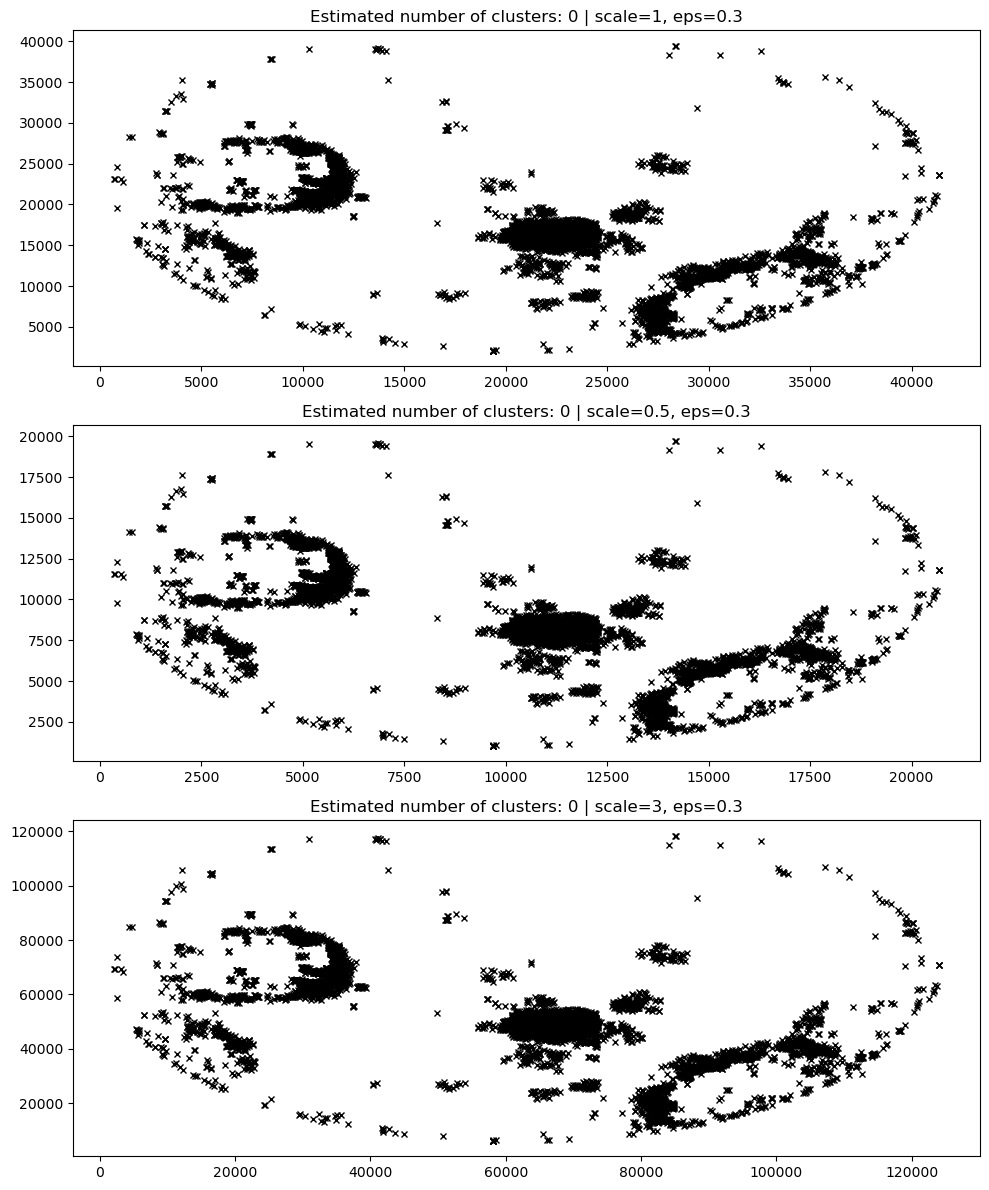

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
dbs = DBSCAN(eps=0.3)
for idx, scale in enumerate([1, 0.5, 3]):
    dbs.fit(X * scale)
    plot(X * scale, dbs.labels_, parameters={"scale": scale, "eps": 0.3}, ax=axes[idx])

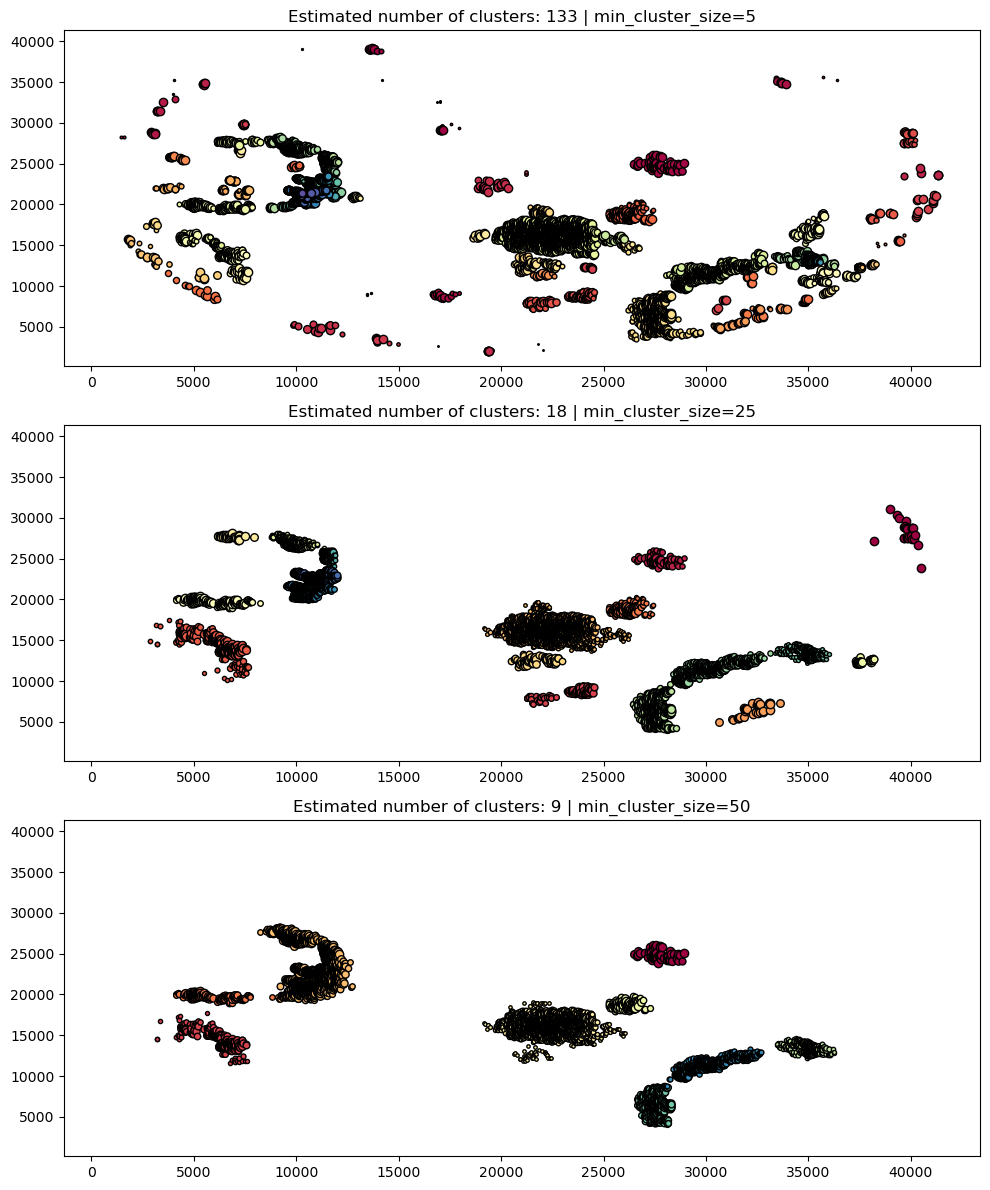

In [33]:
PARAM = ({"min_cluster_size": 5}, {"min_cluster_size": 25}, {"min_cluster_size": 50})
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = HDBSCAN(copy=True, **param).fit(X)
    labels = hdb.labels_

    plot(X, labels, hdb.probabilities_, param, ax=axes[i], hide=True)

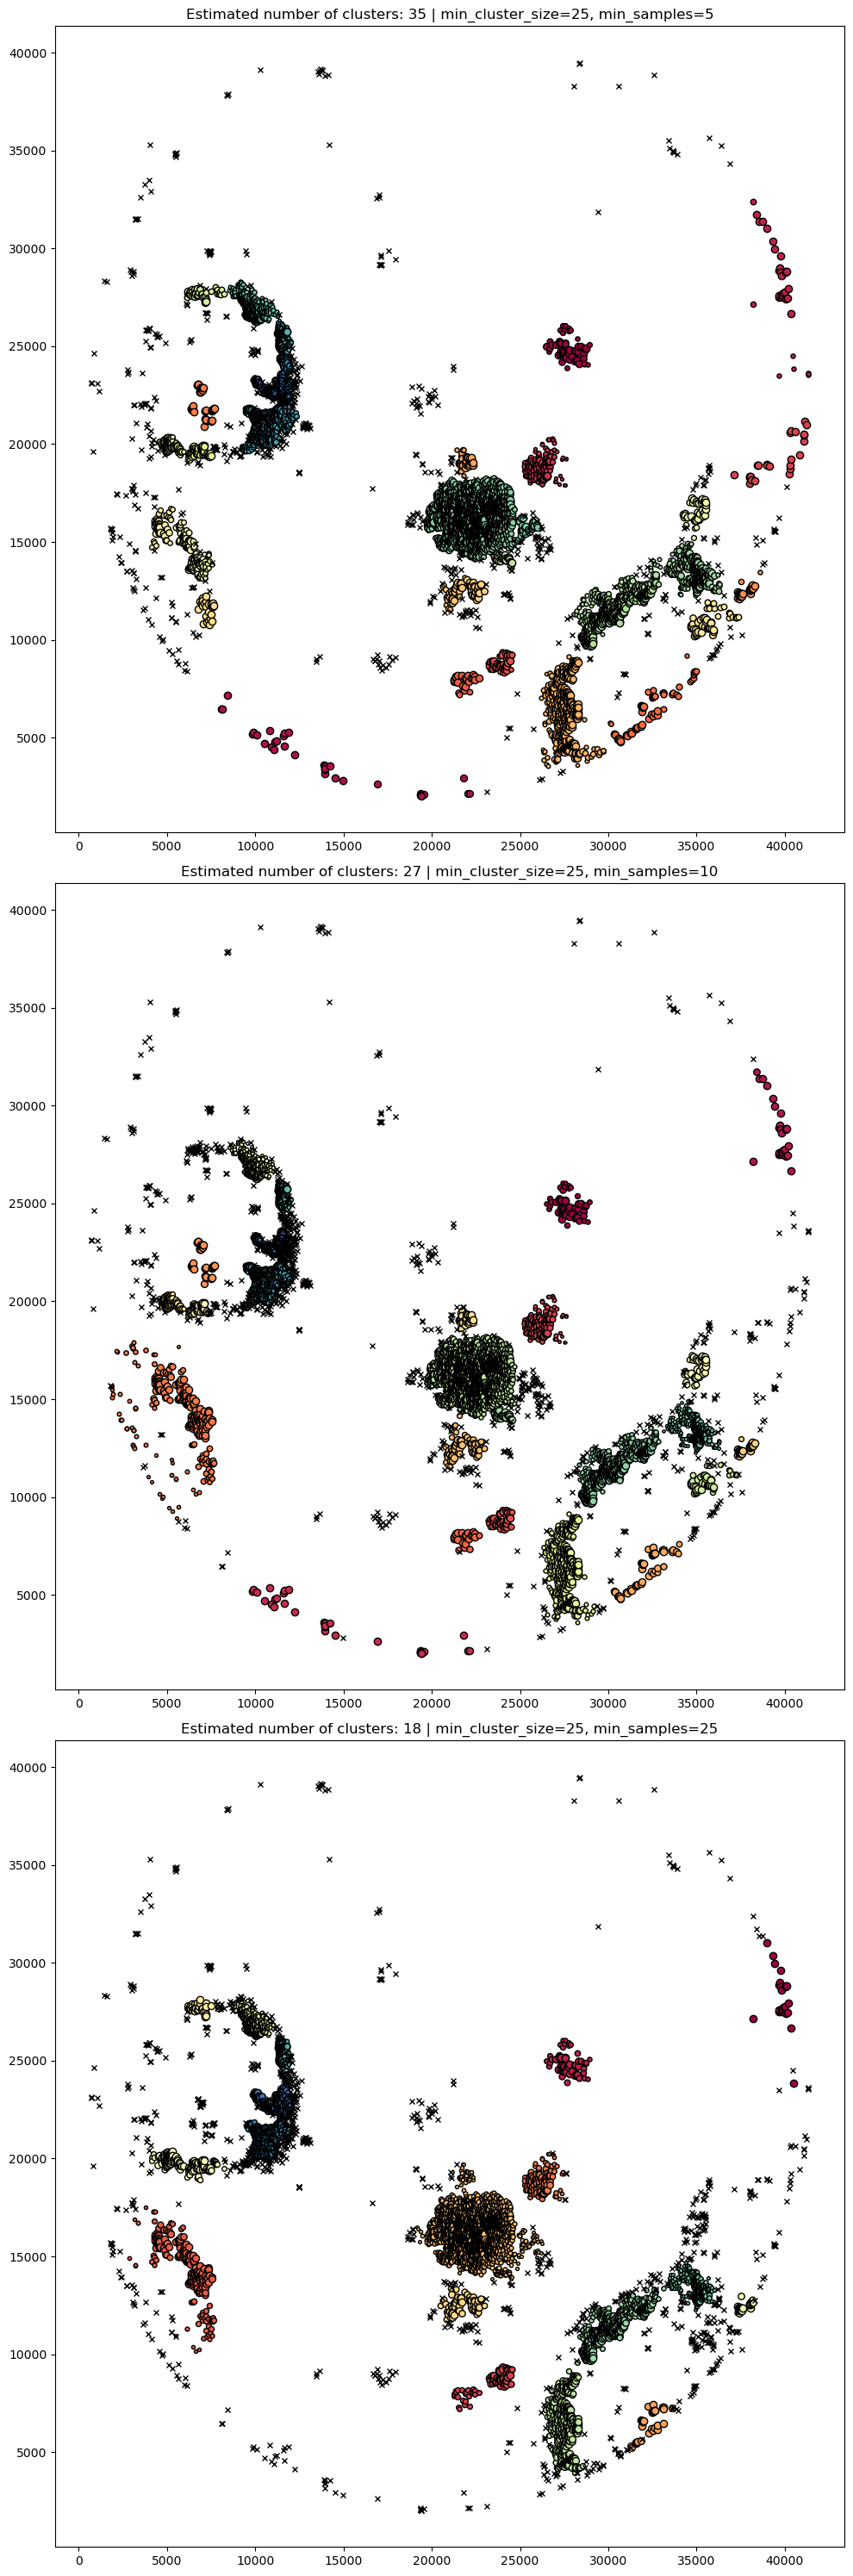

In [44]:
PARAM = (
    {"min_cluster_size": 25, "min_samples": 5},
    {"min_cluster_size": 25, "min_samples": 10},
    {"min_cluster_size": 25, "min_samples": 25},
)
fig, axes = plt.subplots(3, 1, figsize=(10, 30))
for i, param in enumerate(PARAM):
    hdb = HDBSCAN(copy=True, **param).fit(X)
    labels = hdb.labels_

    plot(X, labels, hdb.probabilities_, param, ax=axes[i], hide=False)

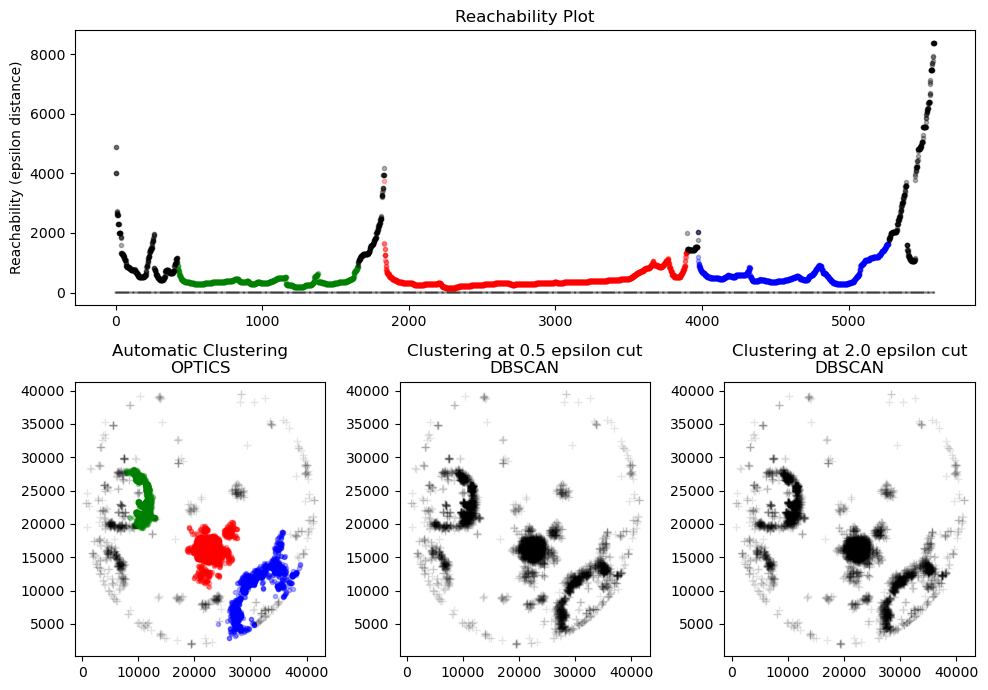

In [18]:
X = coords.values
clust = OPTICS(min_samples=50, xi=0.05, min_cluster_size=0.05)
# Run the fit
clust.fit(X)
labels_050 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=0.5,
)
labels_200 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=2,
)

space = np.arange(len(X))
reachability = clust.reachability_[clust.ordering_]
labels = clust.labels_[clust.ordering_]

plt.figure(figsize=(10, 7))
G = gridspec.GridSpec(2, 3)
ax1 = plt.subplot(G[0, :])
ax2 = plt.subplot(G[1, 0])
ax3 = plt.subplot(G[1, 1])
ax4 = plt.subplot(G[1, 2])

# Reachability plot
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in enumerate(colors):
    Xk = space[labels == klass]
    Rk = reachability[labels == klass]
    ax1.plot(Xk, Rk, color, alpha=0.3)
ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
ax1.set_ylabel("Reachability (epsilon distance)")
ax1.set_title("Reachability Plot")

# OPTICS
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in enumerate(colors):
    Xk = X[clust.labels_ == klass]
    ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax2.plot(X[clust.labels_ == -1, 0], X[clust.labels_ == -1, 1], "k+", alpha=0.1)
ax2.set_title("Automatic Clustering\nOPTICS")

# DBSCAN at 0.5
colors = ["g.", "r.", "b.", "c."]
for klass, color in enumerate(colors):
    Xk = X[labels_050 == klass]
    ax3.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax3.plot(X[labels_050 == -1, 0], X[labels_050 == -1, 1], "k+", alpha=0.1)
ax3.set_title("Clustering at 0.5 epsilon cut\nDBSCAN")

# DBSCAN at 2.
colors = ["g.", "m.", "y.", "c."]
for klass, color in enumerate(colors):
    Xk = X[labels_200 == klass]
    ax4.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax4.plot(X[labels_200 == -1, 0], X[labels_200 == -1, 1], "k+", alpha=0.1)
ax4.set_title("Clustering at 2.0 epsilon cut\nDBSCAN")

plt.tight_layout()
plt.show()

In [ ]:
distances# OPTICS
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in enumerate(colors):
    Xk = X[clust.labels_ == klass]
    ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax2.plot(X[clust.labels_ == -1, 0], X[clust.labels_ == -1, 1], "k+", alpha=0.1)
ax2.set_title("Automatic Clustering\nOPTICS")
